<a href="https://colab.research.google.com/github/shikhaguptadr/ML-PROJECTS/blob/main/computer_vision_Face_Mask_Detection_CNN_(Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

Importing Face Mask Dataset

In [ ]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [ ]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/drive/MyDrive/Colab Notebooks/Toppers Acadmy Data/data/Machine Learning/Computer vision/archive.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Toppers Acadmy Data/data/Machine Learning/Computer vision/archive.zip'

In [ ]:
!ls

data  face-mask-dataset.zip  sample_data


**Importing the Dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_3406.jpg', 'with_mask_3579.jpg', 'with_mask_374.jpg', 'with_mask_1629.jpg', 'with_mask_1749.jpg']
['with_mask_543.jpg', 'with_mask_1079.jpg', 'with_mask_2908.jpg', 'with_mask_1859.jpg', 'with_mask_703.jpg']


In [ ]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1671.jpg', 'without_mask_3692.jpg', 'without_mask_3095.jpg', 'without_mask_1699.jpg', 'without_mask_3477.jpg']
['without_mask_3351.jpg', 'without_mask_93.jpg', 'without_mask_2464.jpg', 'without_mask_1198.jpg', 'without_mask_221.jpg']


In [ ]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [ ]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [ ]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [ ]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

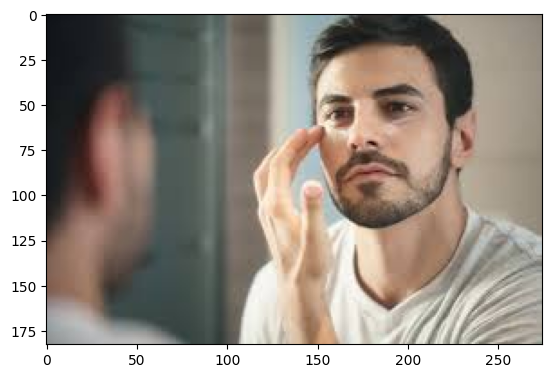

In [ ]:
# displaying with mask image
img = mpimg.imread('/content/data/without_mask/without_mask_1072.jpg')
imgplot = plt.imshow(img)
plt.show()

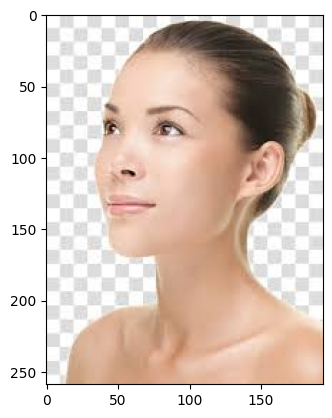

In [ ]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [ ]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[120, 116, 104],
        [128, 124, 112],
        [134, 131, 118],
        ...,
        [189, 174, 133],
        [168, 163, 137],
        [164, 165, 151]],

       [[120, 116, 104],
        [127, 122, 111],
        [133, 130, 117],
        ...,
        [188, 173, 124],
        [169, 163, 139],
        [164, 165, 152]],

       [[119, 115, 103],
        [125, 121, 109],
        [133, 130, 117],
        ...,
        [189, 172, 116],
        [168, 163, 141],
        [165, 166, 153]],

       ...,

       [[202, 194, 175],
        [201, 193, 174],
        [200, 192, 173],
        ...,
        [ 99,  99,  97],
        [ 47,  47,  45],
        [ 60,  60,  58]],

       [[204, 196, 177],
        [205, 197, 178],
        [206, 198, 179],
        ...,
        [109, 109, 107],
        [ 50,  50,  48],
        [ 56,  56,  54]],

       [[205, 197, 178],
        [206, 198, 179],
        [206, 198, 179],
        ...,
        [107, 107, 105],
        [ 55,  55,  53],
        [ 54,  54,  52]]], dtype=uint8)
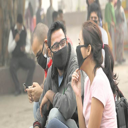

In [ ]:
data[0]

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
data[0].shape

(128, 128, 3)

In [ ]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [ ]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 46,  46,  55],
        [ 44,  45,  50],
        [ 45,  46,  48],
        ...,
        [249, 253, 232],
        [252, 252, 232],
        [253, 252, 231]],

       [[ 45,  45,  56],
        [ 45,  46,  52],
        [ 47,  49,  52],
        ...,
        [251, 252, 232],
        [252, 252, 232],
        [253, 252, 231]],

       [[ 46,  45,  59],
        [ 46,  46,  55],
        [ 45,  46,  51],
        ...,
        [254, 251, 232],
        [254, 252, 233],
        [254, 253, 232]],

       ...,

       [[ 38,  32,  44],
        [ 38,  32,  44],
        [ 38,  32,  44],
        ...,
        [ 35,  27,  40],
        [ 35,  28,  41],
        [ 34,  28,  40]],

       [[ 39,  32,  44],
        [ 38,  31,  44],
        [ 38,  32,  44],
        ...,
        [ 31,  23,  36],
        [ 34,  27,  39],
        [ 33,  27,  39]],

       [[ 38,  30,  43],
        [ 38,  30,  43],
        [ 39,  31,  44],
        ...,
        [ 30,  22,  35],
        [ 31,  23,  36],
        [ 31,  23,  36]]], dtype=uint8)
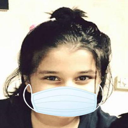

In [ ]:
X_train[0]

In [ ]:
X_train_scaled[0]

array([[[0.18039216, 0.18039216, 0.21568627],
        [0.17254902, 0.17647059, 0.19607843],
        [0.17647059, 0.18039216, 0.18823529],
        ...,
        [0.97647059, 0.99215686, 0.90980392],
        [0.98823529, 0.98823529, 0.90980392],
        [0.99215686, 0.98823529, 0.90588235]],

       [[0.17647059, 0.17647059, 0.21960784],
        [0.17647059, 0.18039216, 0.20392157],
        [0.18431373, 0.19215686, 0.20392157],
        ...,
        [0.98431373, 0.98823529, 0.90980392],
        [0.98823529, 0.98823529, 0.90980392],
        [0.99215686, 0.98823529, 0.90588235]],

       [[0.18039216, 0.17647059, 0.23137255],
        [0.18039216, 0.18039216, 0.21568627],
        [0.17647059, 0.18039216, 0.2       ],
        ...,
        [0.99607843, 0.98431373, 0.90980392],
        [0.99607843, 0.98823529, 0.91372549],
        [0.99607843, 0.99215686, 0.90980392]],

       ...,

       [[0.14901961, 0.1254902 , 0.17254902],
        [0.14901961, 0.1254902 , 0.17254902],
        [0.14901961, 0

**Building a Convolutional Neural Networks (CNN)**

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes = 2

model = keras.Sequential()

# kernel_size=(3, 3): Size of the convolution kernel.
# input_shape=(height, width, channels)
# MaxPooling2D - this layer is added after a convolutional layer to reduce the spatial dimensions of the feature maps
# -and control overfitting by reducing the number of parameters.
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
# It's a common practice to use dropout after fully connected (dense) layers
# or sometimes after convolutional layers to improve generalization.
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - acc: 0.6969 - loss: 0.7121 - val_acc: 0.8793 - val_loss: 0.2807
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - acc: 0.8836 - loss: 0.2957 - val_acc: 0.8942 - val_loss: 0.2629
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - acc: 0.9154 - loss: 0.2139 - val_acc: 0.9058 - val_loss: 0.2368
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - acc: 0.9197 - loss: 0.2156 - val_acc: 0.9339 - val_loss: 0.1855
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.9518 - loss: 0.1331 - val_acc: 0.9190 - val_loss: 0.2117


**Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9345 - loss: 0.1762
Test Accuracy = 0.9285241365432739


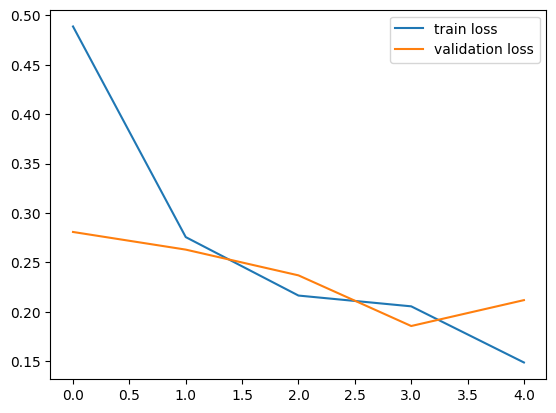

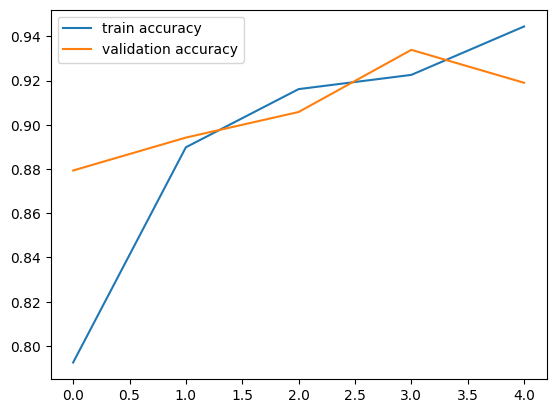

In [ ]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: 


AttributeError: 'NoneType' object has no attribute 'clip'

In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')